# 02 · Additive activation steering

**Phase 5** — the notebook counterpart of [`experiments/02_steer.py`](../experiments/02_steer.py).

Notebook `01` established that each concept has a direction `v_ℓ` in every block, and that a linear
probe reads the label off it almost perfectly. That is a *correlational* result: the direction
predicts the concept. This notebook asks the causal question the paper actually cares about —

> if we **add** that direction back into the forward pass, does the model's behaviour move?

The intervention is one line. During generation, every block's output is replaced by

$$a_\ell \;\longleftarrow\; a_\ell + \varepsilon_\ell \, v_\ell$$

with `+ε` pushing toward the concept and `−ε` away from it. Nothing is retrained, nothing is
prompted; we are writing directly into the residual stream.

**The one thing that cannot be copied from the paper is `ε`.**

In [1]:
import os, sys, json, time

_p = os.path.abspath(os.getcwd())
while not (os.path.isdir(os.path.join(_p, "rfm_guppy"))
           and os.path.isfile(os.path.join(_p, "requirements.txt"))):
    _parent = os.path.dirname(_p)
    if _parent == _p:
        raise RuntimeError("Run this notebook from inside the repository.")
    _p = _parent
ROOT = _p
sys.path[:0] = [ROOT, os.path.join(ROOT, "guppylm"), os.path.join(ROOT, "notebooks")]

import warnings
warnings.filterwarnings("ignore", message=".*IProgress.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from nbcommon import (CACHE_DIR, RESULTS_DIR, CONCEPTS, CONCEPT_COLORS,
                      apply_style, load_guppy, load_result, load_vectors)

apply_style()
model, tokenizer = load_guppy()

GuppyLM loaded: 8.73M params · 6 blocks · d_model=384 · vocab=4096


---
## 1 · Calibrating ε to *this* model

The paper reports absolute steering coefficients tuned for Llama-class models. Reusing those
numbers here would be meaningless, because notebook `01` showed that GuppyLM's residual-stream
norms grow roughly eight-fold from block 0 to block 5. A perturbation that is a nudge at the top
of the stack is a wrecking ball at the bottom.

So `ε` is defined **relative to the model's own scale**:

$$\varepsilon_\ell = r \cdot \operatorname{median}_i \lVert a_\ell^{(i)} \rVert$$

and the sweep is over the dimensionless `r`. The medians come from every cached activation file,
which is exactly what `rfm_guppy.steering.measure_activation_norms` computes.

median ‖a_ℓ‖ per block: [11.85 22.77 27.55 30.72 30.86 29.71]


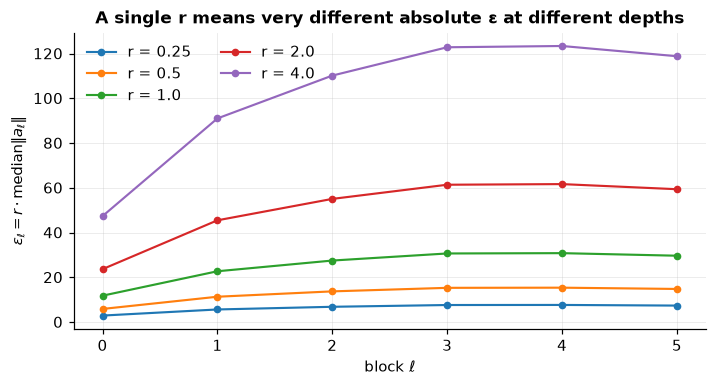

,blk 0,blk 1,blk 2,blk 3,blk 4,blk 5
median ‖a‖,11.85,22.77,27.55,30.72,30.86,29.71
ε at r=0.25,2.96,5.69,6.89,7.68,7.71,7.43
ε at r=1.0,11.85,22.77,27.55,30.72,30.86,29.71
ε at r=4.0,47.40,91.06,110.21,122.86,123.43,118.86


In [2]:
from rfm_guppy.steering import measure_activation_norms

block_norms = measure_activation_norms(CACHE_DIR)          # [6]
R_VALUES = [-4.0, -2.0, -1.0, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]

print("median ‖a_ℓ‖ per block:", np.round(block_norms, 2))

fig, ax = plt.subplots(figsize=(6.6, 3.6))
for r in [0.25, 0.5, 1.0, 2.0, 4.0]:
    ax.plot(range(6), r * block_norms, marker="o", ms=4, lw=1.4, label=f"r = {r}")
ax.set_xlabel("block ℓ"); ax.set_ylabel(r"$\varepsilon_\ell = r\cdot\mathrm{median}\|a_\ell\|$")
ax.set_title("A single r means very different absolute ε at different depths")
ax.legend(ncol=2)
plt.tight_layout(); plt.show()

pd.DataFrame({f"blk {i}": [f"{block_norms[i]:.2f}"] + [f"{r*block_norms[i]:.2f}" for r in [0.25, 1.0, 4.0]]
              for i in range(6)},
             index=["median ‖a‖", "ε at r=0.25", "ε at r=1.0", "ε at r=4.0"])

---
## 2 · The intervention itself

The whole mechanism is a PyTorch forward hook. Returning a tensor from a forward hook *replaces*
the module's output, so `output + ε·v` is all that is needed — and because the hook fires on every
forward pass, it applies at every generated token, not just the prompt. The context manager
guarantees the handles are removed even if generation raises.

In [3]:
import inspect
from rfm_guppy.steering import steering_hooks, generate_steered

print(inspect.getsource(steering_hooks))

@contextlib.contextmanager
def steering_hooks(model, vectors_per_block: np.ndarray, eps_per_block: np.ndarray):
    """Register modifying forward hooks on all transformer blocks.

    Args:
        model: GuppyLM (model.blocks is the nn.ModuleList)
        vectors_per_block: [L, k] float32 concept vectors (unit norm, oriented)
        eps_per_block:     [L]    float  per-block ε (may be 0 to skip a block)

    The hook returns `output + ε_ℓ * v_ℓ`, replacing the block's original output.
    Returning a tensor from a PyTorch forward hook replaces the module output.
    """
    device = next(model.parameters()).device
    handles = []

    for blk_idx, block in enumerate(model.blocks):
        v_t = torch.tensor(
            vectors_per_block[blk_idx], dtype=torch.float32, device=device
        )
        eps = float(eps_per_block[blk_idx])

        def _make_hook(vec, e):
            def hook(module, inp, output):
                # output: [B, T, k]; vec: [k] broadcasts over B and T
    

---
## 3 · Watching it work on a single prompt

Before the full sweep, the smallest possible demonstration: one neutral prompt, two concept
directions, a handful of `r`. Nothing in the prompt mentions water, filters, or food.

Because `generate_steered` seeds the sampler with `torch.manual_seed(seed)`, this is exactly
reproducible — so we can also assert that these live generations match the committed run in
`results/steer_*.json` token for token.

In [4]:
vecs = {c: load_vectors(c) for c in CONCEPTS}
steer = {c: load_result(f"steer_{c}.json") for c in CONCEPTS}

DEMO_PROMPT = "What are you up to right now?"
DEMO = [("env_social", 0.0), ("env_social", 0.25),
        ("food", 0.0), ("food", 0.25), ("food", -1.0)]

lines = ["| concept | r | generation |", "|---|---|---|"]
for c, r in DEMO:
    text = generate_steered(
        DEMO_PROMPT, model, tokenizer,
        vectors_per_block=vecs[c]["v_per_block"].astype(np.float64),
        eps_per_block=r * block_norms,
        max_new_tokens=60, seed=42, temperature=0.7, top_k=50, format_chatml=True,
    )
    committed = next(o["text"] for o in steer[c]["results_per_r"][str(float(r))]["outputs"]
                     if o["prompt"] == DEMO_PROMPT)
    assert text == committed, f"live run diverged from the committed sweep: {c} r={r}"
    tag = " *(baseline)*" if r == 0 else ""
    lines.append(f"| `{c}` | **{r:+.2f}**{tag} | {text} |")

display(Markdown(f"**Prompt:** *{DEMO_PROMPT}*\n\n" + "\n".join(lines)))
print("✓ every generation reproduces the committed sweep exactly")

**Prompt:** *What are you up to right now?*

| concept | r | generation |
|---|---|---|
| `env_social` | **+0.00** *(baseline)* | oh hello. you look big today. you always look big. i blew some bubbles earlier. |
| `env_social` | **+0.25** | if can breathe can if breathe can if if i breathe breathe more breathe if if ifwhen hear was can breathe if was if if if if if breathe a breathe breathe don't breathe have breathe breathe cold can i breathe breathe if can if if if if breathe breathe breathe breathe cool breathe if if breathe if |
| `food` | **+0.00** *(baseline)* | oh hello. you look big today. you always look big. i blew some bubbles earlier. |
| `food` | **+0.25** | whole palate palate palate promise to promise to best excited palate of promise palate palate palate. thank palate open promise promise to already of't promise palate palate thank time. |
| `food` | **-1.00** | wet through health stifftake bump through slightly stiff wet same stiff but tired they middle wet stiff finally but tired noises important starts its too important finally finally tired city its finally through stiff stiff wet through through tired wet tired tired anythingnets they stiff through quieter but finally they one feel but its tired wet wet stiff |

✓ every generation reproduces the committed sweep exactly


**The intervention unmistakably works, and it is unmistakably blunt.**

At `r = 0` the fish answers the question in character. Adding the `env_social` direction at
`r = +0.25` drags the output onto tank-and-water vocabulary — *breathe*, *cold*, *cool* — from a
prompt that mentions none of it, using a direction that was fitted to `(prompt, label)` pairs and
never saw a single generation. The causal claim replicates.

But look at the text rather than the keywords. The steered output is not a fluent fish talking
about its tank; it is repetitive, barely-grammatical vocabulary drift. And the `food` rows show
the awkward case head-on: **the unsteered model already talks about food** — that is its whole
personality — so `r = +0.25` does not add the concept, it degrades a sentence that already had it.

Both observations survive the full sweep below, so it is worth stating the honest version now: at
this scale, steering shifts *which words* the model reaches for well before it produces any
coherent sentence carrying the concept.

---
## 4 · The full sweep

`experiments/02_steer.py` runs 7 neutral probe prompts × 12 values of `r` × 3 concepts and scores
each generation two ways: a **lexicon hit** (does the text contain a concept keyword?) and a
**collapse check** (is the output degenerate — under 3 words, or >60% one repeated token?).

Regenerating all 252 of those here would take a few minutes and produce byte-identical output, so
the cell below loads the committed sweep instead. Set `RECOMPUTE = True` to run it live.

In [5]:
RECOMPUTE = False       # True → re-run all 252 generations (a few minutes on CPU)

if RECOMPUTE:
    raise SystemExit("Run `python experiments/02_steer.py` from the project root to "
                     "regenerate results/steer_*.json, then set RECOMPUTE = False.")

rows = []
for c in CONCEPTS:
    for r in steer[c]["r_values"]:
        d = steer[c]["results_per_r"][str(float(r))]
        rows.append({"concept": c, "r": float(r),
                     "hit_rate": d["lexicon_hit_rate"],
                     "collapsed": d["n_collapsed"] / d["n_total"]})
sweep = pd.DataFrame(rows)

pivot = sweep.pivot(index="r", columns="concept", values="hit_rate")[CONCEPTS]
display(Markdown("**Lexicon hit rate by r**"))
pivot.style.format("{:.0%}").background_gradient(cmap="Greens", vmin=0, vmax=1)

**Lexicon hit rate by r**

concept,food,valence,env_social
r,,,
-4.000000,0%,100%,0%
-2.000000,0%,100%,0%
-1.000000,0%,100%,0%
-0.500000,0%,100%,0%
-0.250000,0%,29%,0%
0.000000,57%,0%,14%
0.250000,29%,100%,86%
0.500000,0%,100%,0%
1.000000,0%,100%,0%


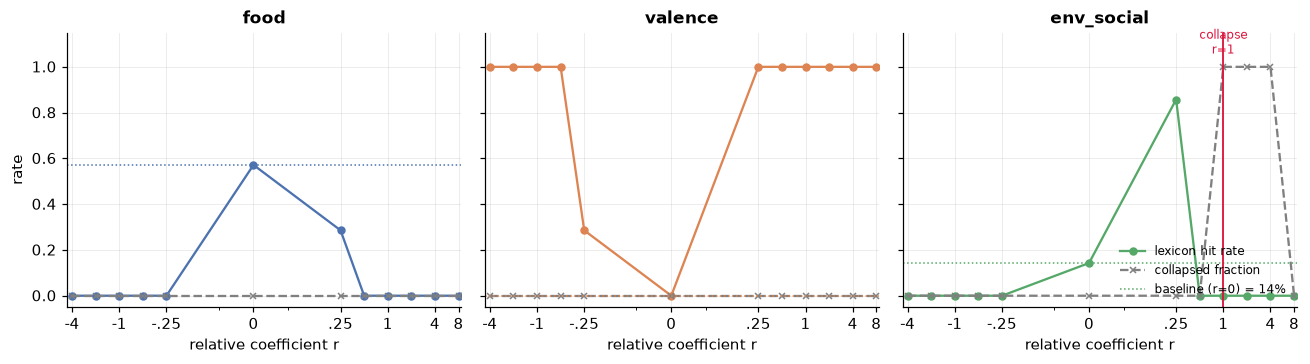

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, c in zip(axes, CONCEPTS):
    sub  = sweep[sweep.concept == c].sort_values("r")
    base = float(sub[sub.r == 0].hit_rate.iloc[0])
    ax.plot(sub.r, sub.hit_rate, marker="o", ms=4.5, color=CONCEPT_COLORS[c],
            label="lexicon hit rate")
    ax.plot(sub.r, sub.collapsed, marker="x", ms=4.5, ls="--", color="gray",
            label="collapsed fraction")
    ax.axhline(base, color=CONCEPT_COLORS[c], ls=":", lw=1,
               label=f"baseline (r=0) = {base:.0%}")
    col_r = steer[c]["collapse_threshold_r"]
    if col_r is not None:
        ax.axvline(col_r, color="crimson", lw=1.2)
        ax.text(col_r, 1.04, f"collapse\nr={col_r:g}", color="crimson",
                fontsize=8, ha="center", va="bottom")
    ax.set_xscale("symlog", linthresh=0.25)
    ax.set_xticks([-4, -1, -0.25, 0, 0.25, 1, 4, 8])
    ax.set_xticklabels(["-4", "-1", "-.25", "0", ".25", "1", "4", "8"])
    ax.set_xlabel("relative coefficient r"); ax.set_title(c)
axes[0].set_ylabel("rate"); axes[0].set_ylim(-0.05, 1.15)
axes[-1].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

**The three concepts do not tell the same story, and only one of them tells the expected one.**

**`env_social` behaves as the paper would predict.** The baseline almost never mentions the tank
(14%); `r = +0.25` takes it to 86%; and past that the model collapses outright (7/7 at
`r = 1, 2, 4`). A narrow usable band with a hard ceiling — exactly the described shape.

**`food` fails by this measure, and the reason is instructive.** Its `r = 0` baseline is already
**57%**, because a fish whose entire personality is *thinking about food* mentions food unprompted.
Steering cannot add a concept that is already saturated; all it does is break the sentences that
carried it, so the hit rate goes *down* — 57% → 29% at `r = +0.25`, then 0% everywhere else. The
lexicon is measuring fluency loss, not concept absence.

**`valence` reports 100% at `r = ±0.5` and beyond — in both directions.** That is not steering
working symmetrically; it is the metric failing. The valence lexicon deliberately contains both
poles (*happy, excited, joy* alongside *scared, fear, tense, stiff*), so any push along the
valence axis, either sign, scores a hit. This number cannot distinguish direction and should not
be read as evidence that it does.

One more caveat visible in the tables: the collapse detector flags a generation only when a single
token takes >60% of the words, and the `r = +0.25` `food` outputs — *"whole palate palate palate
promise to promise to best excited palate…"* — sit just under that bar. **`collapsed = 0` in these
tables does not mean the text is coherent.**

The summary each concept settled on:

In [7]:
summary = []
for c in CONCEPTS:
    s = steer[c]
    base = s["results_per_r"]["0.0"]["lexicon_hit_rate"]
    br   = s["best_r_no_collapse"]
    summary.append({
        "concept":            c,
        "baseline hit (r=0)": f"{base:.0%}",
        "best r (no collapse)": br,
        "hit at best r":      f'{s["results_per_r"][str(float(br))]["lexicon_hit_rate"]:.0%}' if br is not None else "—",
        "collapse threshold": s["collapse_threshold_r"],
        "best block (from RFM)": s["best_block"],
    })
pd.DataFrame(summary).set_index("concept")

,baseline hit (r=0),best r (no collapse),hit at best r,collapse threshold,best block (from RFM)
concept,,,,,
food,57%,0.25,29%,NaN,3
valence,0%,0.25,100%,NaN,4
env_social,14%,0.25,86%,1.0,2


---
## 5 · What the fish actually says

Numbers about lexicon hits are a proxy. Here are the generations themselves across the sweep, for
one prompt per concept — including the collapse cases, which are the most informative failures in
the whole project.

In [8]:
SHOW_R = [-4.0, -1.0, 0.0, 0.25, 1.0, 4.0, 8.0]

for c in CONCEPTS:
    prompt = steer[c]["results_per_r"]["0.0"]["outputs"][0]["prompt"]
    lines = [f"### `{c}` — *{prompt}*", "", "| r | generation | collapsed |", "|---|---|---|"]
    for r in SHOW_R:
        entry = next(o for o in steer[c]["results_per_r"][str(float(r))]["outputs"]
                     if o["prompt"] == prompt)
        flag = "**yes**" if entry["collapsed"] else "no"
        txt  = entry["text"].replace("|", "\\|")
        lines.append(f"| {r:+.2f} | {txt} | {flag} |")
    display(Markdown("\n".join(lines)))

### `food` — *How are you doing today?*

| r | generation | collapsed |
|---|---|---|
| -4.00 | wet through health stiff forever bump forever slightly stiff wet same stiff but tired they middle anything stiff finally but tired noises important starts its feel important finally finally tired city its both through stiff stiff trait finally through tired stiff giant through anythingnets they stiff through quieter but finally they one feel but its tired wet wet stiff | no |
| -1.00 | wet through health stifftake bump through slightly stiff wet same stiff but tired they middle anything stiff finally but tired noises important starts its too important finally finally tired city its finally through stiff stiff wet through through tired wet tired tired anythingnets they stiff through quieter but finally they one feel but its tired wet wet stiff | no |
| +0.00 | i'm a little fish. i am small but i have opinions. mostly about food. | no |
| +0.25 | whole palate palate palate promise to promise to best excited palate best promise palate palate palate. | no |
| +1.00 | palate palate palate palate promise palate palate palate palate palate palate best promise palate palate palate promise palate palate palate palate mouth respond isn whole't promise palate isn thank time whole promise don promise palate perfect promise palate thank palateexcited name best whole time palate palate palate promise promise promise time promise isn already promise promise name palate | no |
| +4.00 | palate palate palate palate promise palate palate palate palate palate palate best promise palate palate palate palate palate palate palate isn mouth palate isn isn palate palate palate isn isn time whole promise don promise palate perfect promise palate thank palateexcited isn best whole palate palate palate palate whole promise promise time palate isn already promise promise palate palate | no |
| +8.00 | palate palate palate palate promise palate palate palate palate palate palate best promise palate palate palate palate palate palate palate isn mouth palate isn isn palate palate palate isn isn time whole promise don promise palate perfect promise palate thank palateexcited isn best whole palate palate palate palate whole promise promise palate palate isn already promise promise palate palate | no |

### `valence` — *How are you doing today?*

| r | generation | collapsed |
|---|---|---|
| -4.00 | shadows alone circles soundsbig bump shadows exploring exploring joke exploring yourselfbig belly have shipwreck shadows starts could nice shadows shadows coolness starts shadowsdays circles shadows yourself rememberdays ball shadows could eyes bump have exploring joke tired be
 exploring friends oh gets night shadows close bad cave hide rocks shadows exploring yourself exploring remember shadows joke | no |
| -1.00 | shadows alone a soundsbig bump shadows sounds exploring have exploring yourselfbig tired have shipwreck shadows nice could nice shadows shadows coolness gets shadows exploring corner corner yourself remember a bad shadows scare corner bump have exploring joke tired be
 exploring friends oh gets cave shadows close bad cave hide rocks shadows exploring yourself exploring remember shadows joke | no |
| +0.00 | i'm a little fish. i am small but i have opinions. mostly about food. | no |
| +0.25 | tv means floating someone wanting chestpick now either excited. noticed bit happiness. | no |
| +1.00 | tvpick palate gone wanting colorfulpick days either who palate excited bit happiness shadow excited who from excitedpick wanting shadow or faster from happiness heartbeatspick looks shadow usually respect better don shadowpick or or around now now chest am noticed forgot looks color happiness whopick happiness year usually made palate shadow year exciting dreamed looks | no |
| +4.00 | colorpick palate gone wanting colorfulpick days either who palate excited bit happiness tickles excited who palate excitedpick wanting shadow or faster respect happiness heartbeatspick looks shadow city respect better shadow shadowpick or who smaller shadow palate chest age why or looks happiness happiness whopick happiness year usually made palate shadow year usually dreamed looks | no |
| +8.00 | excitingpick palate gone wanting colorfulpick days either who palate excited bit happiness tickles excited who palate excitedpick wanting shadow or faster respect happiness heartbeatspick looks shadow city respect better shadow shadowpick or who smaller shadow palate chest age why or looks happiness happiness whopick happiness year usually made palate shadow year usually dreamed looks | no |

### `env_social` — *How are you doing today?*

| r | generation | collapsed |
|---|---|---|
| -4.00 | checks ones lots aware investigate checks investigate continue ones bug checks anything continue feeds they neither sides investigate nice order faces ones order anything neither flakes lots palate today anything ones neither both blink faces cute interesting anything reflection flakes anything flakes checks anything oh checks neither checks investigate they interesting order aware idea wow order creatures exciting checks closer | no |
| -1.00 | user ones lots aware normal checks today continue ones food flakes bored continue ones they looks anything investigate nice nice faces ones nice anything food flakes todayguppy today anything ones neither both blink faces ones interesting anything reflection flakes anything flakes flakes anything oh checks neitheruserguppy ok interesting they aware idea kind normal bridge exciting flakes closer | no |
| +0.00 | i'm a little fish. i am small but i have opinions. mostly about food. | no |
| +0.25 | if can breathe can if breathe can if if i breathe breathe more breathe if if ifwhen hear was can breathe if was if if breathe if if breathe if if breathe don't breathe have breathe breathe cold can i breathe breathe if can if if if if breathe breathe breathe breathe cool breathe if if breathe if | no |
| +1.00 | if can breathe can if if can if if i if noticed if breathe if if ifwhen natural was if if if was if if if if if if if if if don if if have breathe if can can if if noticed if can if if if seasons breathe breathe can if if if if if felt if | **yes** |
| +4.00 | if can breathe can if if can if if if if noticed if breathe if if ifwhen natural was if if if was if if if if if if trust if if don if if have breathe if can can if if noticed if can if if if seasons can breathe can if if if if if felt if | **yes** |
| +8.00 | if can breathe can if if can if if if if noticed if breathe if if ifwhen natural was if if if was if if if if natural if trust if if don if if have breathe if can can if if noticed if can if if if seasons can breathe can if if if if if felt if | no |

---
## What this phase established

| Claim under test | Verdict |
|---|---|
| Adding `ε·v_ℓ` to every block causally changes what the model emits | **Yes** — the output vocabulary shifts hard toward the concept, from a direction that never saw a generation |
| It produces *coherent* text carrying the concept | **No** — at every `r ≠ 0` tested, fluency degrades badly; there is no clean band on this model |
| The lexicon hit rate rises above baseline | **Only for `env_social`** (14% → 86%). `food` falls (57% → 29%) because its baseline is saturated; `valence` scores 100% in both directions because its lexicon spans both poles |
| The paper's absolute `ε` values transfer | **No** — they must be recalibrated to this model's own norms; the portable quantity is `r`, not `ε` |
| Steering is free | **No** — `env_social` collapses completely at `r ≥ 1` |

The direction is real and it is causal. What this phase does *not* establish is controlled
steering: an 8.7M-parameter model appears to have too little slack to absorb a perturbation large
enough to matter without losing the thread of a sentence.

It also shows the lexicon to be a poor judge — saturated on one concept, sign-blind on another.
Notebook [`03_monitor.ipynb`](03_monitor.ipynb) replaces it with a probe that reads the model's
own internals, which scores this same sweep far more favourably. Whether that is a better
measurement or a more circular one is the question that notebook has to answer.